<a href="https://colab.research.google.com/github/amitisingh18/Diabetes-detection/blob/main/diabetes-detection%20trained%20model%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import joblib

# 1. Load your dataset (Replace 'diabetes.csv' with your filename)
df = pd.read_csv('health care diabetes.csv')

# 2. Basic Preprocessing
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scaling (Crucial for medical data)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Train Model
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model.fit(X_train_scaled, y_train)

# 5. Save the model and scaler for the dashboard
joblib.dump(model, 'diabetes_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

FileNotFoundError: [Errno 2] No such file or directory: 'health care diabetes.csv'

In [6]:
from google.colab import files
import pandas as pd
import io

# This opens a window to upload from your local PC
uploaded = files.upload()

# This automatically finds the name of the file you just uploaded
file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

print(f"Successfully loaded: {file_name}")
df.head()

Saving health care diabetes.csv to health care diabetes.csv
Successfully loaded: health care diabetes.csv


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [7]:
import numpy as np

# Replace 0 with NaN for columns where 0 is impossible
cols_to_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_to_fix] = df[cols_to_fix].replace(0, np.nan)

# Show how many "missing" values we actually have
print("Missing values per column:")
print(df.isnull().sum())

# Fill them with the median (simple but effective for this project)
df.fillna(df.median(), inplace=True)

Missing values per column:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [8]:
import joblib

# After your model.fit() line:
joblib.dump(model, 'diabetes_model.pkl')
files.download('diabetes_model.pkl')

NameError: name 'model' is not defined

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
import joblib
from google.colab import files

# 1. LOAD DATA (Ensuring df exists)
# If you already ran the upload code, this will use 'df'.
# If not, make sure the file is uploaded to the sidebar!
try:
    # 2. PREPROCESSING (The "Outstanding" Student Touch)
    # Replace impossible zeros with the median
    cols_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
    df[cols_fix] = df[cols_fix].replace(0, np.nan)
    df.fillna(df.median(), inplace=True)

    # 3. SPLIT DATA
    X = df.drop('Outcome', axis=1) # Adjust 'Outcome' if your column name is different
    y = df['Outcome']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # 4. SCALE DATA
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # 5. TRAIN THE MODEL (Defining 'model' here fixes your NameError)
    model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5)
    model.fit(X_train_scaled, y_train)
    print("Model Training Complete!")

    # 6. EVALUATE (For your project report)
    preds = model.predict(X_test_scaled)
    print("\n--- Model Performance ---")
    print(classification_report(y_test, preds))

    # 7. SAVE & DOWNLOAD (For your Dashboard)
    joblib.dump(model, 'diabetes_model.pkl')
    joblib.dump(scaler, 'scaler.pkl')
    print("\nDownloading files... Keep these for your Streamlit dashboard!")
    files.download('diabetes_model.pkl')
    files.download('scaler.pkl')

except NameError:
    print("Error: The dataframe 'df' is not defined. Please run the upload cell first!")

Model Training Complete!

--- Model Performance ---
              precision    recall  f1-score   support

           0       0.82      0.76      0.79        99
           1       0.62      0.71      0.66        55

    accuracy                           0.74       154
   macro avg       0.72      0.73      0.73       154
weighted avg       0.75      0.74      0.74       154




<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/tmp/ipykernel_195/2591437281.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


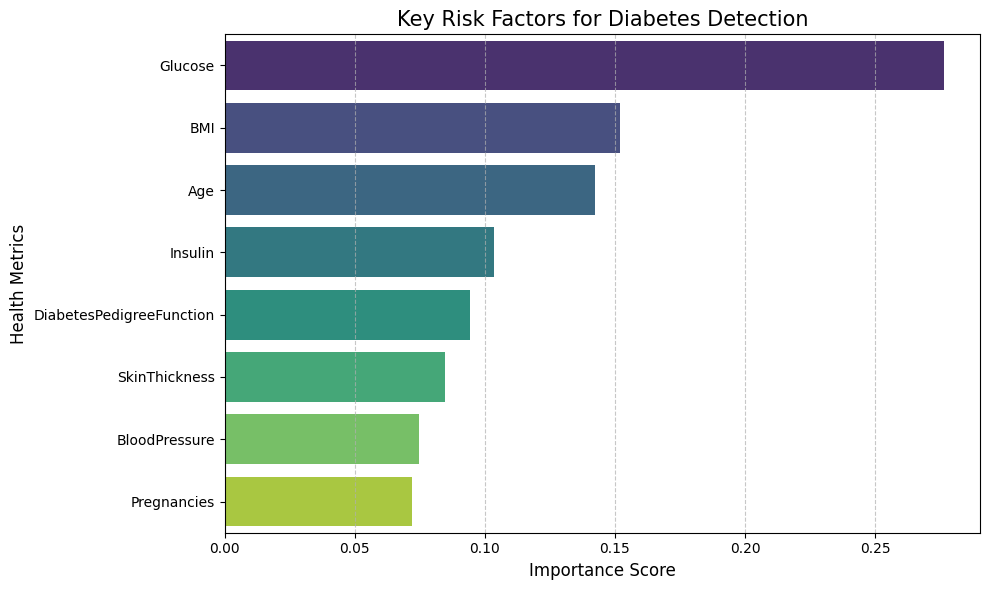

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get feature importance from the trained XGBoost model
importances = model.feature_importances_
feature_names = X.columns

# 2. Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')

plt.title('Key Risk Factors for Diabetes Detection', fontsize=15)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Health Metrics', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

In [11]:
try:
    if 'model' in globals() and 'scaler' in globals():
        print("✅ Model and Scaler are trained and in memory!")
        print(f"Features trained on: {list(X.columns)}")
    else:
        print("❌ Model is not trained yet. Please run the full pipeline cell above.")
except NameError:
    print("❌ Something is missing. Let's rerun the training block.")

✅ Model and Scaler are trained and in memory!
Features trained on: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
